In [69]:
import gymnasium as gym
import random
import numpy as np
from IPython.display import Image
import matplotlib.pyplot as plt

In [70]:
env = gym.make("FrozenLake-v1", is_slippery = False)
env.reset()
env.render()

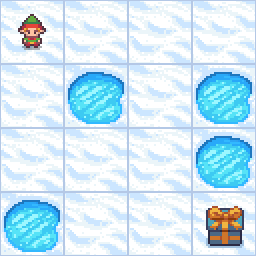

In [71]:
import imageio

def generate_frozen_lake_gif(env, filename="frozen_lake_animation.gif", duration=100):
    frames = []
    state, info = env.reset()
    for t in range(50): # Simulate 50 steps
        frames.append(env.render())
        action = env.action_space.sample() # Take a random action
        state, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            break
    env.close()
    imageio.mimsave(filename, frames, duration=duration)
    return filename

# Create a new environment instance for rendering
render_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
gif_filename = generate_frozen_lake_gif(render_env)
Image(filename=gif_filename, width=400)

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
print("State space: ", env.observation_space.n)
print("Action space: ", env.action_space.n)

State space:  16
Action space:  4


In [74]:
# Our table has the following dimensions:
# (rows x columns) = (states x actions) = (16 x 4)

nb_states = env.observation_space.n  # = 16
nb_actions = env.action_space.n      # = 4
qtable = np.zeros((nb_states, nb_actions))

In [75]:
# Let's see how it looks
print('Q-table =')
print(qtable)

Q-table =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [76]:
episodes = 1000        # Total number of episodes
alpha = 0.5            # Learning rate
gamma = 0.9            # Discount factor
epsilon = 1.0          # Amount of randomness in the action selection
epsilon_decay = 0.001  # Fixed amount to decrease

In [77]:
outcomes = []

for _ in range(episodes):
  state, info = env.reset()
  done = False
  outcomes.append("Failure")
  while not done :
    rnd = np.random.random()

    if rnd< epsilon :
      action = env.action_space.sample()
    else :
      action = np.argmax(qtabla[state])
    new_state , reward , done, _, info = env.step(action)


    qtable[state, action] = qtable[state, action] + alpha *(reward + gamma * np.max(qtable[new_state]) - qtable[state, action])
    state = new_state
    if reward :
      outcomes[-1] = "Success"
espislon = max(epsilon - epsilon_decay,0)


In [78]:
print('===========================================')
print('Q-table after training:')
print(qtable)

Q-table after training:
[[0.5283688  0.58623119 0.58709268 0.52834671]
 [0.52834892 0.         0.65232845 0.58708701]
 [0.58683195 0.72491401 0.58617481 0.65220472]
 [0.65190509 0.         0.58571473 0.58245968]
 [0.58622331 0.65136821 0.         0.52827793]
 [0.         0.         0.         0.        ]
 [0.         0.80553605 0.         0.65087794]
 [0.         0.         0.         0.        ]
 [0.6511748  0.         0.72411916 0.58617881]
 [0.65042644 0.79696053 0.80499258 0.        ]
 [0.72296481 0.89534283 0.         0.70576457]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.70800842 0.88835449 0.70559014]
 [0.74375244 0.89170532 0.99902344 0.78626258]
 [0.         0.         0.         0.        ]]


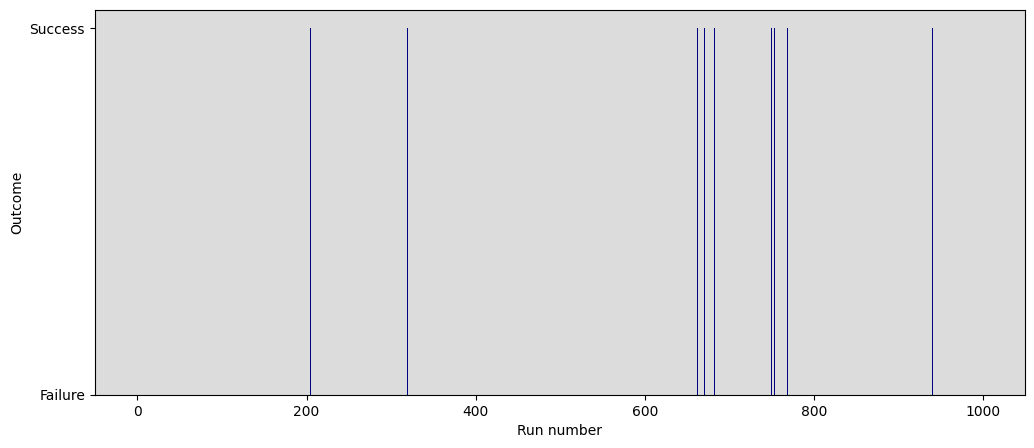

In [79]:
plt.figure(figsize=(12, 5))
plt.xlabel("Run number")
plt.ylabel("Outcome")
ax = plt.gca()
ax.set_facecolor('gainsboro')
plt.bar(range(len(outcomes)), outcomes, color="navy", width=1.0)
plt.show()

In [80]:
episodes = 1
nb_success = 0

state, info = env.reset()
done = False

print("\n🔵 Initial State:")
env.render()

step = 0

while not done:
    step += 1

    # Choose best action from Q-table
    action = np.argmax(qtable[state])

    # Take action
    new_state, reward, done, _, info = env.step(action)

    # Display step info
    print("\n" + "="*40)
    print(f"Step {step}")
    print(f"Action taken: {action}")
    print(f"Reward: {reward}")
    print(f"Done: {done}")
    print("="*40)

    # Render environment (FrozenLake-style grid)
    env.render()

    # Update state
    state = new_state

    # Track success
    nb_success += reward

# Final result
print("\n🏁 Episode finished!")


🔵 Initial State:

Step 1
Action taken: 2
Reward: 0
Done: False

Step 2
Action taken: 2
Reward: 0
Done: False

Step 3
Action taken: 1
Reward: 0
Done: False

Step 4
Action taken: 1
Reward: 0
Done: False

Step 5
Action taken: 1
Reward: 0
Done: False

Step 6
Action taken: 2
Reward: 1
Done: True

🏁 Episode finished!
